In [6]:
import pandas as pd
import numpy as np
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re
import warnings
warnings.filterwarnings('ignore')

# Load the cleaned dataset
df = pd.read_csv('../data/resume_data_cleaned.csv')
nlp = spacy.load('en_core_web_sm')
print(f"Dataset shape: {df.shape}")
print("Loaded successfully!")

Dataset shape: (9320, 20)
Loaded successfully!


In [7]:
def clean_text(text):
    """
    Clean and normalize text:
    - Lowercase
    - Remove special characters
    - Remove stopwords
    - Lemmatize but protect tech terms
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''
    
    # Remove brackets and quotes from list-like strings
    text = re.sub(r"[\[\]'\"{}]", ' ', text)
    
    # Lowercase and remove special characters
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s,]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # spaCy processing
    doc = nlp(text)
    tokens = [token.text for token in doc  # use text not lemma_ to avoid datum issue
              if not token.is_stop 
              and not token.is_punct 
              and len(token.text) > 1]
    
    return ' '.join(tokens)

# Test it
sample = df['skills'].iloc[0]
print("Original:")
print(sample[:200])
print()
print("Cleaned:")
print(clean_text(sample)[:200])

Original:
['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapreduce', 'Spark', 'Java', 'Machine Learning', 'Cloud', 'Hdfs', 'YARN', 'Core Java', 'Data Science', 'C++', 'Data Structures', 'DBMS', 'RDBMS', 'Informatica

Cleaned:
big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science data structures dbms rdbms informatica talend amazon redshift microsoft azure


In [8]:
# Apply cleaning to all relevant text columns
print("Cleaning text columns... this may take a minute")

text_columns = [
    'skills',
    'career_objective', 
    'responsibilities',
    'skills_required',
    'experiencere_requirement',
    'major_field_of_studies',
    'degree_names',
    'positions'
]

for col in text_columns:
    print(f"Cleaning {col}...")
    df[f'{col}_cleaned'] = df[col].astype(str).apply(clean_text)

print("Done!")
print(f"Dataset shape: {df.shape}")

Cleaning text columns... this may take a minute
Cleaning skills...
Cleaning career_objective...
Cleaning responsibilities...
Cleaning skills_required...
Cleaning experiencere_requirement...
Cleaning major_field_of_studies...
Cleaning degree_names...
Cleaning positions...
Done!
Dataset shape: (9320, 28)


In [9]:
df.to_csv('../data/resume_data_featured.csv', index=False)
print("Saved!")
print(f"Shape: {df.shape}")
print(f"New cleaned columns: {[col for col in df.columns if col.endswith('_cleaned')]}")

Saved!
Shape: (9320, 28)
New cleaned columns: ['skills_cleaned', 'career_objective_cleaned', 'responsibilities_cleaned', 'skills_required_cleaned', 'experiencere_requirement_cleaned', 'major_field_of_studies_cleaned', 'degree_names_cleaned', 'positions_cleaned']


In [10]:
def extract_skills(text):
    """Convert cleaned skills string into a set of individual skills"""
    if not isinstance(text, str) or text.strip() == '':
        return set()
    return set([skill.strip() for skill in text.split() if skill.strip() != ''])

def skill_overlap_features(row):
    """
    Calculate how much the resume skills overlap with required skills
    """
    resume_skills = extract_skills(row['skills_cleaned'])
    required_skills = extract_skills(row['skills_required_cleaned'])
    
    if len(required_skills) == 0:
        return 0, 0
    
    # How many required skills does the resume have
    overlap = resume_skills.intersection(required_skills)
    
    # Raw count of matching skills
    overlap_count = len(overlap)
    
    # What percentage of required skills are covered
    overlap_pct = len(overlap) / len(required_skills)
    
    return overlap_count, overlap_pct

# Apply to dataset
df[['skill_overlap_count', 'skill_overlap_pct']] = df.apply(
    skill_overlap_features, axis=1, result_type='expand'
)

print("Sample results:")
print(df[['skills_cleaned', 'skills_required_cleaned', 
          'skill_overlap_count', 'skill_overlap_pct']].head())
print()
print(df[['skill_overlap_count', 'skill_overlap_pct']].describe())

Sample results:
                                      skills_cleaned  \
0  big data hadoop hive python mapreduce spark ja...   
1  data analysis data analytics business analysis...   
2  software development machine learning deep lea...   
3  accounts payables accounts receivables account...   
4  analytical reasoning compliance testing knowle...   

                             skills_required_cleaned  skill_overlap_count  \
0                                                                     0.0   
1                                                                     0.0   
2  brand promotion campaign management field supe...                  0.0   
3  fast typing skill ieltsinternet browsing onlin...                  0.0   
4  ios ios app developer ios application developm...                  0.0   

   skill_overlap_pct  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                0.0  

       skill_overlap_count  skill_overlap_pct

In [11]:
# Look at a few rows where overlap is 0
zero_overlap = df[df['skill_overlap_count'] == 0][
    ['skills_cleaned', 'skills_required_cleaned']
].head(5)

for i, row in zero_overlap.iterrows():
    print(f"--- Row {i} ---")
    print(f"Resume skills: {row['skills_cleaned'][:150]}")
    print(f"Required skills: {row['skills_required_cleaned'][:150]}")
    print()

--- Row 0 ---
Resume skills: big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science data structures dbms rdbms informatica talend
Required skills: 

--- Row 1 ---
Resume skills: data analysis data analytics business analysis sas powerbi tableau data visualization business analytics machine learning
Required skills: 

--- Row 2 ---
Resume skills: software development machine learning deep learning risk assessment requirement gathering application support javascript python docker html hive css
Required skills: brand promotion campaign management field supervision merchandising promotional activities trade marketing

--- Row 3 ---
Resume skills: accounts payables accounts receivables accounts payable accounts receivable administrative functions trial balance banking budget bi closing computer 
Required skills: fast typing skill ieltsinternet browsing online work ability

--- Row 4 ---
Resume skills: analytical reasoning compliance testing 

In [12]:
# Check if empty skills_required correlates with low matched_score
empty_required = df[df['skills_required_cleaned'].str.strip() == '']
non_empty_required = df[df['skills_required_cleaned'].str.strip() != '']

print(f"Rows with empty skills_required: {len(empty_required)}")
print(f"Average score when empty: {empty_required['matched_score'].mean():.3f}")
print()
print(f"Rows with non-empty skills_required: {len(non_empty_required)}")
print(f"Average score when non-empty: {non_empty_required['matched_score'].mean():.3f}")
print()

# Check overlap_pct only for non-empty required skills
non_empty_overlap = df[df['skills_required_cleaned'].str.strip() != '']['skill_overlap_pct']
print(f"Overlap % for non-empty rows:")
print(non_empty_overlap.describe())

Rows with empty skills_required: 1661
Average score when empty: 0.730

Rows with non-empty skills_required: 7659
Average score when non-empty: 0.647

Overlap % for non-empty rows:
count    7659.000000
mean        0.055944
std         0.116038
min         0.000000
25%         0.000000
50%         0.000000
75%         0.071429
max         1.000000
Name: skill_overlap_pct, dtype: float64


In [13]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load the model - this downloads it first time, may take a minute
print("Loading sentence transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded!")

Loading sentence transformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded!


In [14]:
def compute_semantic_similarity(text1, text2):
    """
    Compute semantic similarity between two texts
    Returns a score between 0 and 1
    """
    if not isinstance(text1, str) or not isinstance(text2, str):
        return 0
    if text1.strip() == '' or text2.strip() == '':
        return 0
    
    # Generate embeddings
    embeddings = model.encode([text1, text2])
    
    # Compute cosine similarity
    similarity = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]
    
    return float(similarity)

# Test it before applying to whole dataset
test_resume = "python machine learning data science sql pandas numpy"
test_jd = "machine learning engineer python deep learning"
test_unrelated = "marketing sales brand management customer service"

print(f"Related match score:   {compute_semantic_similarity(test_resume, test_jd):.3f}")
print(f"Unrelated match score: {compute_semantic_similarity(test_resume, test_unrelated):.3f}")

Related match score:   0.451
Unrelated match score: 0.084


In [15]:
print("Computing semantic similarities... this will take a few minutes")

# Skills similarity - most important
print("1/4 - Computing skills similarity...")
df['skills_semantic_sim'] = df.apply(
    lambda row: compute_semantic_similarity(
        row['skills_cleaned'], 
        row['skills_required_cleaned']
    ), axis=1
)

# Responsibilities similarity
print("2/4 - Computing responsibilities similarity...")
df['responsibilities_semantic_sim'] = df.apply(
    lambda row: compute_semantic_similarity(
        row['responsibilities_cleaned'],
        row['skills_required_cleaned']
    ), axis=1
)

# Career objective similarity
print("3/4 - Computing career objective similarity...")
df['objective_semantic_sim'] = df.apply(
    lambda row: compute_semantic_similarity(
        row['career_objective_cleaned'],
        row['skills_required_cleaned']
    ), axis=1
)

# Education similarity
print("4/4 - Computing education similarity...")
df['education_semantic_sim'] = df.apply(
    lambda row: compute_semantic_similarity(
        row['major_field_of_studies_cleaned'],
        row['skills_required_cleaned']
    ), axis=1
)

print("Done!")

Computing semantic similarities... this will take a few minutes
1/4 - Computing skills similarity...
2/4 - Computing responsibilities similarity...
3/4 - Computing career objective similarity...
4/4 - Computing education similarity...
Done!


In [16]:
# Check correlation of new features with matched_score
semantic_cols = [
    'skills_semantic_sim',
    'responsibilities_semantic_sim', 
    'objective_semantic_sim',
    'education_semantic_sim',
    'skill_overlap_count',
    'skill_overlap_pct'
]

print("Correlation with matched_score:")
for col in semantic_cols:
    corr = df[col].corr(df['matched_score'])
    print(f"  {col}: {corr:.3f}")

Correlation with matched_score:
  skills_semantic_sim: 0.014
  responsibilities_semantic_sim: -0.092
  objective_semantic_sim: -0.060
  education_semantic_sim: -0.020
  skill_overlap_count: 0.113
  skill_overlap_pct: 0.119


In [17]:
# Check what matched_score actually correlates with
print("Checking matched_score against job position match:")

# Does same category = higher score?
df['position_in_skills'] = df.apply(
    lambda row: 1 if any(
        word in str(row['skills_cleaned']).lower() 
        for word in str(row['job_position_name']).lower().split()
    ) else 0, axis=1
)

print(df.groupby('position_in_skills')['matched_score'].mean())
print()

# Distribution of matched_score by job position
print("Score variance by job position:")
print(df.groupby('job_position_name')['matched_score'].agg(['mean', 'std', 'min', 'max']).to_string())

Checking matched_score against job position match:
position_in_skills
0    0.647999
1    0.705974
Name: matched_score, dtype: float64

Score variance by job position:
                                                                                             mean       std       min       max
job_position_name                                                                                                              
AI Engineer                                                                              0.754855  0.098703  0.210000  0.916667
Asst. Manager/ Manger (Administrative)                                                   0.743360  0.093647  0.350000  0.950000
Business Development Executive                                                           0.518248  0.147513  0.173333  0.850000
Civil Engineer                                                                           0.502884  0.187749  0.050000  0.850000
Data Engineer                                                    

In [18]:
# Look at highest and lowest scoring rows in detail
print("=== TOP 5 HIGHEST SCORING ROWS ===")
top = df.nlargest(5, 'matched_score')[['job_position_name', 'skills', 'skills_required', 'matched_score']]
for i, row in top.iterrows():
    print(f"\nJob: {row['job_position_name']}")
    print(f"Score: {row['matched_score']}")
    print(f"Resume skills: {str(row['skills'])[:150]}")
    print(f"Required skills: {str(row['skills_required'])[:150]}")

print("\n=== BOTTOM 5 LOWEST SCORING ROWS ===")
bottom = df.nsmallest(5, 'matched_score')[['job_position_name', 'skills', 'skills_required', 'matched_score']]
for i, row in bottom.iterrows():
    print(f"\nJob: {row['job_position_name']}")
    print(f"Score: {row['matched_score']}")
    print(f"Resume skills: {str(row['skills'])[:150]}")
    print(f"Required skills: {str(row['skills_required'])[:150]}")

=== TOP 5 HIGHEST SCORING ROWS ===

Job: Full Stack Developer (Python,React js)
Score: 0.95
Resume skills: ['Data Science', 'Machine Learning', 'Artificial Intelligence', 'Data Analysis', 'Keras', 'Tensorflow', 'Pytorch', 'Python', 'AWS', 'Kubernetes', 'Kaf
Required skills: nan

Job: Asst. Manager/ Manger (Administrative)
Score: 0.95
Resume skills: ['ASP.NET 4.5', 'academic', 'Clustering', 'consulting', 'curriculum development', 'customer satisfaction', 'data analysis', 'data mining', 'data wareh
Required skills: •Administration
•Health Safety and Environment
•Safety and Security Management

Job: Management Trainee - Mechanical
Score: 0.95
Resume skills: ['Testing', 'Troubleshooting', 'Embedded Hardware & Software', 'Microprocessors', 'Computer systems', 'Hardware & Software design', 'Digital signal pr
Required skills: Computer skill
Good communication skills
Mechanical Engineering
Quick learner and hard working

Job: Asst. Manager/ Manger (Administrative)
Score: 0.95
Resume skills: ['

In [19]:
# Create a combined resume text feature
df['resume_full_text'] = (
    df['skills_cleaned'] + ' ' + 
    df['career_objective_cleaned'] + ' ' + 
    df['responsibilities_cleaned']
)

# Create a combined job text feature  
df['job_full_text'] = (
    df['job_position_name'].str.lower() + ' ' + 
    df['skills_required_cleaned'] + ' ' +
    df['experiencere_requirement_cleaned']
)

# Compute similarity between full resume and job title + requirements
print("Computing full text similarity...")
df['full_text_semantic_sim'] = df.apply(
    lambda row: compute_semantic_similarity(
        row['resume_full_text'],
        row['job_full_text']
    ), axis=1
)

# Check correlation
corr = df['full_text_semantic_sim'].corr(df['matched_score'])
print(f"\nFull text similarity correlation with matched_score: {corr:.3f}")

Computing full text similarity...

Full text similarity correlation with matched_score: 0.121


In [20]:
# Define domain keyword mappings
domain_keywords = {
    'tech': [
        'python', 'machine learning', 'data science', 'artificial intelligence',
        'deep learning', 'sql', 'java', 'javascript', 'react', 'node',
        'aws', 'cloud', 'docker', 'kubernetes', 'devops', 'software',
        'programming', 'developer', 'engineer', 'database', 'api',
        'tensorflow', 'pytorch', 'keras', 'nlp', 'computer vision',
        'full stack', 'backend', 'frontend', 'ios', 'android', 'mobile',
        'it', 'information technology', 'system administrator',
        'network', 'server', 'infrastructure', 'technical support',
        'helpdesk', 'cybersecurity', 'it executive', 'it officer'
    ],
    'data': [
        'data analysis', 'data analytics', 'business intelligence',
        'tableau', 'powerbi', 'excel', 'statistics', 'visualization',
        'reporting', 'dashboard', 'data warehouse', 'etl', 'hadoop',
        'spark', 'big data', 'data engineer', 'data science'
    ],
    'engineering': [
        'autocad', 'civil', 'mechanical', 'structural', 'construction',
        'site engineer', 'electrical', 'architecture', 'blueprint',
        'project management', 'manufacturing', 'embedded', 'hardware',
        'microprocessor', 'circuit', 'cad', 'etabs', 'ms project'
    ],
    'finance': [
        'accounting', 'audit', 'vat', 'budget', 'banking', 'finance',
        'accounts payable', 'accounts receivable', 'tax', 'financial',
        'bookkeeping', 'compliance', 'internal control', 'treasury',
        'quickbooks', 'tally', 'ifrs', 'gaap'
    ],
    'marketing': [
        'marketing', 'sales', 'brand', 'campaign', 'trade marketing',
        'business development', 'customer', 'market research',
        'digital marketing', 'seo', 'social media', 'advertising',
        'merchandising', 'promotional', 'crm'
    ],
    'admin': [
        'administration', 'hr', 'human resources', 'office management',
        'recruitment', 'payroll', 'operations', 'administrative',
        'secretary', 'coordinator', 'management trainee', 'executive'
    ]
}

def classify_domain(text):
    """
    Classify text into a domain based on keyword matching
    Returns the best matching domain and its score
    """
    if not isinstance(text, str) or text.strip() == '':
        return 'unknown', 0
    
    text = text.lower()
    domain_scores = {}
    
    for domain, keywords in domain_keywords.items():
        # Count how many domain keywords appear in text
        score = sum(1 for keyword in keywords if keyword in text)
        domain_scores[domain] = score
    
    # Get best matching domain
    best_domain = max(domain_scores, key=domain_scores.get)
    best_score = domain_scores[best_domain]
    
    if best_score == 0:
        return 'unknown', 0
        
    return best_domain, best_score

# Test it
test_cases = [
    "python machine learning data science tensorflow",
    "autocad civil structural construction site engineer",
    "accounting audit vat budget banking compliance",
    "marketing sales brand campaign business development",
    "administration hr human resources recruitment payroll"
]

print("Domain classification tests:")
for test in test_cases:
    domain, score = classify_domain(test)
    print(f"  '{test[:50]}...' → {domain} (score: {score})")

Domain classification tests:
  'python machine learning data science tensorflow...' → tech (score: 4)
  'autocad civil structural construction site enginee...' → engineering (score: 6)
  'accounting audit vat budget banking compliance...' → finance (score: 6)
  'marketing sales brand campaign business developmen...' → marketing (score: 5)
  'administration hr human resources recruitment payr...' → admin (score: 5)


In [21]:
def compute_domain_alignment(resume_text, job_text):
    """
    Compare resume domain vs job domain
    Returns alignment score between 0 and 1
    """
    resume_domain, resume_score = classify_domain(resume_text)
    job_domain, job_score = classify_domain(job_text)
    
    # If either is unknown we can't align
    if resume_domain == 'unknown' or job_domain == 'unknown':
        return 0.5  # neutral score for unknown domains
    
    # Same domain = full alignment
    if resume_domain == job_domain:
        return 1.0
    
    # Define partial matches - related domains
    partial_matches = {
        ('tech', 'data'): 0.7,      # tech and data are closely related
        ('data', 'tech'): 0.7,
        ('tech', 'engineering'): 0.4,
        ('engineering', 'tech'): 0.4,
        ('finance', 'admin'): 0.3,
        ('admin', 'finance'): 0.3,
    }
    
    # Check for partial match
    pair = (resume_domain, job_domain)
    if pair in partial_matches:
        return partial_matches[pair]
    
    # Completely different domains
    return 0.0

# Apply to dataset
print("Computing domain alignment...")
df['resume_domain'] = df['resume_full_text'].apply(
    lambda x: classify_domain(x)[0]
)
df['job_domain'] = df['job_full_text'].apply(
    lambda x: classify_domain(x)[0]
)
df['domain_alignment'] = df.apply(
    lambda row: compute_domain_alignment(
        row['resume_full_text'],
        row['job_full_text']
    ), axis=1
)

# Check results
print("\nDomain alignment distribution:")
print(df['domain_alignment'].value_counts())
print()
print(f"Correlation with matched_score: {df['domain_alignment'].corr(df['matched_score']):.3f}")
print()
print("Average matched_score by domain alignment:")
print(df.groupby('domain_alignment')['matched_score'].mean().sort_index())

Computing domain alignment...

Domain alignment distribution:
domain_alignment
1.0    4920
0.0    2856
0.4    1047
0.7     351
0.3     144
0.5       2
Name: count, dtype: int64

Correlation with matched_score: 0.284

Average matched_score by domain alignment:
domain_alignment
0.0    0.616715
0.3    0.781479
0.4    0.531908
0.5    0.683333
0.7    0.663243
1.0    0.711649
Name: matched_score, dtype: float64


Our score distribution:
count    9320.000000
mean        0.343228
std         0.189554
min         0.007300
25%         0.157950
50%         0.438000
75%         0.484025
max         0.929700
Name: our_score, dtype: float64

Correlation with original matched_score: 0.301



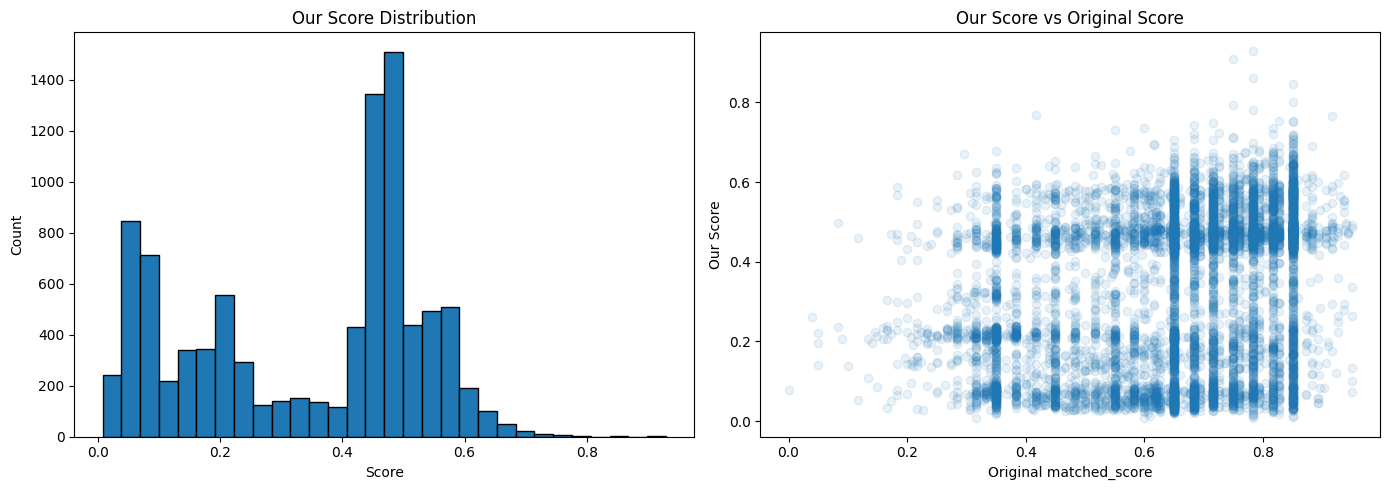

In [22]:
def compute_our_score(row):
    """
    Our custom match score:
    - Domain alignment:      40%
    - Skill overlap:         30%
    - Semantic similarity:   20%
    - Has certification:     10%
    """
    domain  = row['domain_alignment']          * 0.40
    skills  = row['skill_overlap_pct']         * 0.30
    semantic = row['full_text_semantic_sim']   * 0.20
    cert    = row['has_certification']         * 0.10
    
    score = domain + skills + semantic + cert
    
    # Normalize to 0-1 range
    return round(min(max(score, 0), 1), 4)

# Apply to dataset
df['our_score'] = df.apply(compute_our_score, axis=1)

# Check results
print("Our score distribution:")
print(df['our_score'].describe())
print()
print(f"Correlation with original matched_score: {df['our_score'].corr(df['matched_score']):.3f}")
print()

# Visualize
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Our score distribution
axes[0].hist(df['our_score'], bins=30, edgecolor='black')
axes[0].set_title('Our Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Our score vs original matched_score
axes[1].scatter(df['matched_score'], df['our_score'], alpha=0.1)
axes[1].set_title('Our Score vs Original Score')
axes[1].set_xlabel('Original matched_score')
axes[1].set_ylabel('Our Score')

plt.tight_layout()
plt.show()

In [23]:
# Check our score by domain alignment - sanity check
print("Average OUR score by domain:")
print(df.groupby('domain_alignment')['our_score'].mean().sort_index())
print()

# Check a few high and low scoring examples
print("=== TOP 5 BY OUR SCORE ===")
top = df.nlargest(5, 'our_score')[['job_position_name', 'resume_domain', 'job_domain', 'our_score', 'matched_score']]
print(top.to_string())
print()
print("=== BOTTOM 5 BY OUR SCORE ===")
bottom = df.nsmallest(5, 'our_score')[['job_position_name', 'resume_domain', 'job_domain', 'our_score', 'matched_score']]
print(bottom.to_string())


Average OUR score by domain:
domain_alignment
0.0    0.099207
0.3    0.260072
0.4    0.259427
0.5    0.339300
0.7    0.405073
1.0    0.500735
Name: our_score, dtype: float64

=== TOP 5 BY OUR SCORE ===
        job_position_name resume_domain   job_domain  our_score  matched_score
1736  Mechanical Designer   engineering  engineering     0.9297       0.783333
982   Mechanical Designer   engineering  engineering     0.9089       0.750000
6412          AI Engineer          tech         tech     0.8607       0.783333
336           AI Engineer          tech         tech     0.8449       0.850000
7213  Mechanical Designer   engineering  engineering     0.8012       0.850000

=== BOTTOM 5 BY OUR SCORE ===
                                                job_position_name resume_domain job_domain  our_score  matched_score
4900                                              Executive - VAT          tech    finance     0.0073       0.783333
5158                      Sr.Officer / Executive - Internal

In [24]:
# Check what's being misclassified
print("Job domain distribution:")
print(df['job_domain'].value_counts())
print()
print("Resume domain distribution:")
print(df['resume_domain'].value_counts())
print()

# Check IT Executive specifically
it_exec = df[df['job_position_name'].str.contains('IT', na=False)]
print("IT Executive job domains:")
print(it_exec[['job_position_name', 'job_domain', 'job_full_text']].head(3).to_string())

Job domain distribution:
job_domain
tech           4988
engineering    1335
admin          1000
finance         999
marketing       666
data            332
Name: count, dtype: int64

Resume domain distribution:
resume_domain
tech           7020
finance        1048
marketing       613
engineering     358
data            210
admin            69
unknown           2
Name: count, dtype: int64

IT Executive job domains:
               job_position_name job_domain                        job_full_text
19  Executive/ Sr. Executive -IT       tech  executive/ sr. executive -it  years
34  Executive/ Sr. Executive -IT       tech  executive/ sr. executive -it  years
41  Executive/ Sr. Executive -IT       tech  executive/ sr. executive -it  years


In [25]:
# Check finance resumes being misclassified as tech
finance_jobs = df[df['job_domain'] == 'finance']
print("Finance job - resume domain distribution:")
print(finance_jobs['resume_domain'].value_counts())
print()

# Look at a tech-classified resume for a finance job
tech_in_finance = finance_jobs[finance_jobs['resume_domain'] == 'tech']
print("Sample tech resume applying for finance job:")
print(tech_in_finance[['skills', 'resume_domain', 'job_domain']].head(3).to_string())
print()

# Check what tech keywords are triggering in finance resumes
sample = tech_in_finance['skills_cleaned'].iloc[0]
print("Skills of misclassified resume:")
print(sample[:300])

Finance job - resume domain distribution:
resume_domain
tech           717
finance        196
engineering     40
marketing       29
data            14
admin            3
Name: count, dtype: int64

Sample tech resume applying for finance job:
                                                                                                                                                                                                                                                    skills resume_domain job_domain
24  ['Data Analysis', 'Business Analysis', 'Machine Learning', 'Regression Analysis', 'Time Series Analysis', 'SQL', 'Base SAS', 'Python', 'NLP', 'Credit Risk', 'Tableau', 'Statistical Analysis', 'Data Visualization', 'Data Science', 'R', 'Power Bi']          tech    finance
26     ['Econometrics', 'Problem Solving', 'Data Analytics', 'Data Modeling', 'Data Validation', 'Data Reporting', 'Business Intelligence', 'Data Manipulation', 'Data Mining', 'Machine Learning', 'R Program

In [26]:
def compute_domain_vector(text):
    """
    Instead of one domain label, return a score for every domain
    """
    if not isinstance(text, str) or text.strip() == '':
        return {domain: 0 for domain in domain_keywords}
    
    text = text.lower()
    vector = {}
    
    for domain, keywords in domain_keywords.items():
        score = sum(1 for keyword in keywords if keyword in text)
        vector[domain] = score
        
    return vector

def compute_multilabel_alignment(resume_text, job_text):
    """
    Compute alignment across all domains simultaneously
    """
    resume_vector = compute_domain_vector(resume_text)
    job_vector = compute_domain_vector(job_text)
    
    # Normalize both vectors to 0-1
    resume_total = sum(resume_vector.values()) or 1
    job_total = sum(job_vector.values()) or 1
    
    resume_norm = {d: s/resume_total for d, s in resume_vector.items()}
    job_norm = {d: s/job_total for d, s in job_vector.items()}
    
    # Compute dot product similarity between domain vectors
    alignment = sum(resume_norm[d] * job_norm[d] for d in domain_keywords)
    
    return round(alignment, 4)

# Test it on our problematic cases
test_cases = [
    # Data scientist applying for finance
    ("python sql machine learning data science credit risk ifrs", 
     "accounting finance audit banking compliance"),
    # Perfect tech match
    ("python machine learning tensorflow deep learning",
     "machine learning engineer python aws"),
    # Complete mismatch
    ("python machine learning data science",
     "autocad civil structural construction"),
]

print("Multi-label alignment tests:")
for resume, job in test_cases:
    score = compute_multilabel_alignment(resume, job)
    print(f"  Resume: '{resume[:50]}'")
    print(f"  Job:    '{job[:50]}'")
    print(f"  Alignment: {score:.4f}")
    print()

Multi-label alignment tests:
  Resume: 'python sql machine learning data science credit ri'
  Job:    'accounting finance audit banking compliance'
  Alignment: 0.2381

  Resume: 'python machine learning tensorflow deep learning'
  Job:    'machine learning engineer python aws'
  Alignment: 1.0000

  Resume: 'python machine learning data science'
  Job:    'autocad civil structural construction'
  Alignment: 0.0000



In [27]:
# Apply multilabel alignment to full dataset
print("Computing multilabel domain alignment...")
df['domain_alignment_v2'] = df.apply(
    lambda row: compute_multilabel_alignment(
        row['resume_full_text'],
        row['job_full_text']
    ), axis=1
)

# Compare old vs new
print(f"Old domain alignment correlation: {df['domain_alignment'].corr(df['matched_score']):.3f}")
print(f"New domain alignment correlation: {df['domain_alignment_v2'].corr(df['matched_score']):.3f}")
print()
print("New alignment distribution:")
print(df['domain_alignment_v2'].describe())

Computing multilabel domain alignment...


Old domain alignment correlation: 0.284
New domain alignment correlation: 0.351

New alignment distribution:
count    9320.000000
mean        0.401070
std         0.234622
min         0.000000
25%         0.222200
50%         0.333300
75%         0.550000
max         1.000000
Name: domain_alignment_v2, dtype: float64


In [28]:
def compute_our_score_v2(row):
    """
    Our improved custom match score:
    - Domain alignment v2:   40%
    - Skill overlap:         30%
    - Semantic similarity:   20%
    - Has certification:     10%
    """
    domain   = row['domain_alignment_v2']      * 0.40
    skills   = row['skill_overlap_pct']        * 0.30
    semantic = row['full_text_semantic_sim']   * 0.20
    cert     = row['has_certification']        * 0.10
    
    score = domain + skills + semantic + cert
    return round(min(max(score, 0), 1), 4)

# Apply
df['our_score_v2'] = df.apply(compute_our_score_v2, axis=1)

# Check results
print("Our score v2 distribution:")
print(df['our_score_v2'].describe())
print()
print(f"Correlation with original matched_score: {df['our_score_v2'].corr(df['matched_score']):.3f}")
print()

# Sanity check - top and bottom
print("=== TOP 5 BY OUR SCORE V2 ===")
top = df.nlargest(5, 'our_score_v2')[
    ['job_position_name', 'resume_domain', 
     'job_domain', 'our_score_v2', 'matched_score']
]
print(top.to_string())
print()
print("=== BOTTOM 5 BY OUR SCORE V2 ===")
bottom = df.nsmallest(5, 'our_score_v2')[
    ['job_position_name', 'resume_domain', 
     'job_domain', 'our_score_v2', 'matched_score']
]
print(bottom.to_string())


Our score v2 distribution:
count    9320.000000
mean        0.262080
std         0.111037
min         0.025100
25%         0.178175
50%         0.246350
75%         0.338800
max         0.794000
Name: our_score_v2, dtype: float64

Correlation with original matched_score: 0.353

=== TOP 5 BY OUR SCORE V2 ===
        job_position_name resume_domain   job_domain  our_score_v2  matched_score
6412          AI Engineer          tech         tech        0.7940       0.783333
336           AI Engineer          tech         tech        0.7834       0.850000
1736  Mechanical Designer   engineering  engineering        0.7297       0.783333
9048          AI Engineer          tech         tech        0.6862       0.850000
982   Mechanical Designer   engineering  engineering        0.6756       0.750000

=== BOTTOM 5 BY OUR SCORE V2 ===
        job_position_name resume_domain job_domain  our_score_v2  matched_score
2756      Executive - VAT          tech    finance        0.0251       0.850000
4034 

In [29]:
# Our score v2 becomes our new target
# Let's also create binary labels for classification
df['fit_label'] = (df['our_score_v2'] >= 0.25).astype(int)

# Just update the threshold directly on existing our_score_v2
df['fit_label'] = (df['our_score_v2'] >= 0.25).astype(int)

print("Updated fit label distribution:")
print(df['fit_label'].value_counts())
print(f"Fit rate: {df['fit_label'].mean()*100:.1f}%")
print()

# Final feature set
feature_cols = [
    'domain_alignment_v2',
    'skill_overlap_count',
    'skill_overlap_pct',
    'full_text_semantic_sim',
    'skills_semantic_sim',
    'has_certification',
    'our_score_v2'
]

print("Final feature correlations with our_score_v2:")
for col in feature_cols[:-1]:
    corr = df[col].corr(df['our_score_v2'])
    print(f"  {col}: {corr:.3f}")

# Save final dataset
df.to_csv('../data/resume_data_featured.csv', index=False)
print("\nSaved!")
print(f"Final shape: {df.shape}")

Updated fit label distribution:
fit_label
0    4751
1    4569
Name: count, dtype: int64
Fit rate: 49.0%

Final feature correlations with our_score_v2:
  domain_alignment_v2: 0.842
  skill_overlap_count: 0.319
  skill_overlap_pct: 0.309
  full_text_semantic_sim: 0.409
  skills_semantic_sim: 0.123
  has_certification: 0.333

Saved!
Final shape: (9320, 45)


In [30]:
# Check score distribution to find better threshold
import numpy as np

thresholds = [0.20, 0.25, 0.30, 0.35]
for t in thresholds:
    fit_rate = (df['our_score_v2'] >= t).mean() * 100
    print(f"Threshold {t}: fit rate = {fit_rate:.1f}%")

Threshold 0.2: fit rate = 67.0%
Threshold 0.25: fit rate = 49.0%
Threshold 0.3: fit rate = 34.7%
Threshold 0.35: fit rate = 22.7%


In [31]:
# Drop weak/negative features
cols_to_drop = [
    'responsibilities_semantic_sim',
    'objective_semantic_sim',
    'education_semantic_sim'
]
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(f"Shape after dropping weak features: {df.shape}")

Shape after dropping weak features: (9320, 42)


In [32]:
df.to_csv('resume_data_final.csv', index=False)
print("Saved!")
print(f"Final shape: {df.shape}")
print(f"Fit rate: {df['fit_label'].mean()*100:.1f}%")

Saved!
Final shape: (9320, 42)
Fit rate: 49.0%


In [33]:
# Test in a notebook cell
import sys
sys.path.append('..')
from src.pdf_parser import parse_resume

# Read your CV
with open('../data/Abdurahim Sanginov CV.pdf', 'rb') as f:
    pdf_bytes = f.read()

result = parse_resume(pdf_bytes)

print(f"Name: {result['name']}")
print(f"Email: {result['email']}")
print(f"LinkedIn: {result['linkedin']}")
print(f"GitHub: {result['github']}")
print(f"Degree: {result['degree']}")
print(f"GPA: {result['gpa']}")
print(f"\nSkills found: {result['skills_keywords']}")
print(f"\nEducation section:\n{result['education'][:300]}")
print(f"\nExperience section:\n{result['experience'][:300]}")

Name: Abdurahim Sanginov
Email: asangino@ramapo.edu
LinkedIn: linkedin.com/in/abdurahim-sanginov
GitHub: github.com/Abdurahim0202
Degree: BACHELOR
GPA: 3.85

Skills found: ['python', 'r', 'machine learning', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'data analysis']

Education section:
Bachelor of Science (B.S.) – Computer Science | Minor: Mathematics (GPA: 3.85 / 4.0)                    Aug 2024 – May 2028 Ramapo College of New Jersey, Mahwah, NJ  Achievements: Presidential Scholarship (2024 – 2028), Dean’s List (Fall 2024, Spring 2025, Fall 2025, Spring 2026).  Related Course 

Experience section:
Assistive Technology Assistant Oct 2024 – Present Ramapo College of New Jersey  Enhance learning outcomes for 50+ students by integrating advanced assistive technologies to maximize accessibility.  Adapt 20+ AI tools, including large language models, to support students in reading, writing, and co


In [34]:
def education_level_score(text):
    """
    Score education level: higher = more advanced degree
    """
    if not isinstance(text, str):
        return 0
    text = text.lower()
    if any(w in text for w in ['phd', 'doctorate', 'doctoral']):
        return 4
    elif any(w in text for w in ['master', 'msc', 'm.s', 'mba']):
        return 3
    elif any(w in text for w in ['bachelor', 'b.s', 'b.a', 'undergraduate']):
        return 2
    elif any(w in text for w in ['associate', 'diploma']):
        return 1
    else:
        return 0

def education_match_score(row):
    """
    Compare candidate education level to job requirement
    Returns 1.0 if meets/exceeds, 0.5 if close, 0.0 if far below
    """
    candidate_level = education_level_score(str(row['degree_names']))
    required_level = education_level_score(str(row['educationaL_requirements']))
    
    if required_level == 0:
        return 1.0  # no requirement specified, don't penalize
    
    diff = candidate_level - required_level
    if diff >= 0:
        return 1.0
    elif diff == -1:
        return 0.5
    else:
        return 0.0

df['education_match'] = df.apply(education_match_score, axis=1)

print("Education match distribution:")
print(df['education_match'].value_counts())
print()
print(f"Correlation with matched_score: {df['education_match'].corr(df['matched_score']):.3f}")

Education match distribution:
education_match
1.0    4248
0.0    3833
0.5    1239
Name: count, dtype: int64

Correlation with matched_score: 0.112


In [35]:
    # Sanity check - does education match make intuitive sense?
print("Average matched_score by education_match level:")
print(df.groupby('education_match')['matched_score'].mean())
print()

# Distribution check
print("How many rows have each education match level:")
print(df['education_match'].value_counts())

Average matched_score by education_match level:
education_match
0.0    0.636555
0.5    0.686522
1.0    0.676964
Name: matched_score, dtype: float64

How many rows have each education match level:
education_match
1.0    4248
0.0    3833
0.5    1239
Name: count, dtype: int64


In [38]:
def extract_required_experience(text):
    """
    Extract years of experience required from job description
    Handles formats like 'At least 5 years', '1 to 3 years'
    """
    if not isinstance(text, str):
        return 0
    
    text = text.lower()
    
    patterns = [
        r'at least (\d+)',           # "at least 5 years"
        r'(\d+)\s*to\s*\d+\s*years?', # "1 to 3 years" - takes lower bound
        r'(\d+)\+?\s*years?'          # general fallback
    ]
    
    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return int(match.group(1))
    
    return 0

# Reapply to the job side
df['required_experience_years'] = df['experiencere_requirement'].astype(str).apply(
    extract_required_experience
)

print("Required experience distribution:")
print(df['required_experience_years'].value_counts().sort_index())

Required experience distribution:
required_experience_years
0     1332
1     1999
2      998
3     1662
4      665
5     2331
15     333
Name: count, dtype: int64


In [39]:
import ast

def count_positions(text):
    """
    Count number of positions/roles listed for the candidate
    More positions generally suggests more experience
    """
    if not isinstance(text, str):
        return 0
    try:
        positions_list = ast.literal_eval(text)
        if isinstance(positions_list, list):
            return len(positions_list)
    except:
        pass
    return 0

df['candidate_position_count'] = df['positions'].astype(str).apply(count_positions)

print("Candidate position count distribution:")
print(df['candidate_position_count'].value_counts().sort_index())

Candidate position count distribution:
candidate_position_count
1     3724
2      952
3     1770
4     1326
5      588
6      440
7      312
8      112
9       68
10      28
Name: count, dtype: int64


In [40]:
def experience_match_score(row):
    """
    Compare candidate position count (proxy for experience) to required years
    """
    candidate_proxy = row['candidate_position_count']
    required_years = row['required_experience_years']
    
    if required_years == 0:
        return 1.0  # no requirement, don't penalize
    
    # Rough mapping: each position ~ 1-2 years experience
    estimated_years = candidate_proxy * 1.5
    
    diff = estimated_years - required_years
    if diff >= 0:
        return 1.0
    elif diff >= -2:
        return 0.5
    else:
        return 0.0

df['experience_match'] = df.apply(experience_match_score, axis=1)

print("Experience match distribution:")
print(df['experience_match'].value_counts())
print()
print(f"Correlation with matched_score: {df['experience_match'].corr(df['matched_score']):.3f}")
print()
print("Average matched_score by experience_match level:")
print(df.groupby('experience_match')['matched_score'].mean())

Experience match distribution:
experience_match
1.0    5976
0.5    1818
0.0    1526
Name: count, dtype: int64

Correlation with matched_score: 0.136

Average matched_score by experience_match level:
experience_match
0.0    0.601640
0.5    0.674343
1.0    0.673059
Name: matched_score, dtype: float64


In [41]:
# Save updated dataset with new features
df.to_csv('../data/resume_data_final.csv', index=False)
print("Saved!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved!
Shape: (9320, 47)
Columns: ['career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'major_field_of_studies', 'professional_company_names', 'start_dates', 'end_dates', 'related_skils_in_job', 'positions', 'responsibilities', 'job_position_name', 'educationaL_requirements', 'experiencere_requirement', 'responsibilities.1', 'skills_required', 'matched_score', 'has_certification', 'has_links', 'skills_cleaned', 'career_objective_cleaned', 'responsibilities_cleaned', 'skills_required_cleaned', 'experiencere_requirement_cleaned', 'major_field_of_studies_cleaned', 'degree_names_cleaned', 'positions_cleaned', 'skill_overlap_count', 'skill_overlap_pct', 'skills_semantic_sim', 'position_in_skills', 'resume_full_text', 'job_full_text', 'full_text_semantic_sim', 'resume_domain', 'job_domain', 'domain_alignment', 'our_score', 'domain_alignment_v2', 'our_score_v2', 'fit_label', 'education_match', 'candidate_experience_years', 'required_experience_years'